# Clean-Label Poisoning — End-to-End Training (Attack 2 + Defense)

## Setup

In [1]:

import os, json, time, copy, random, hashlib
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

print("torch", torch.__version__, "| CUDA", torch.cuda.is_available())

torch 2.10.0+cu128 | CUDA True


## Config

In [2]:

SEED = 406

TRAIN_SAMPLES_PER_CLASS = 200
TEST_SAMPLES_PER_CLASS  = 1000

TARGET_CLASS = 0        # airplane
BASE_CLASS   = 6        # frog
NUM_POISONS  = 50
NUM_TRIALS   = 10       
WATERMARK_OPACITY = 0.30
CRAFT_STEPS  = 500
CRAFT_LR     = 0.01
CRAFT_BETA   = 0.1
CRAFT_EPSILON = 0.06

PRETRAIN_EPOCHS = 30
PRETRAIN_LR     = 1e-4
RETRAIN_EPOCHS  = 10
RETRAIN_LR      = 2e-5
BATCH_SIZE      = 128
NUM_BYSTANDERS  = 40
OUTLIER_TARGETS = True

DEFENSE_K = 10
DEFENSE_MAX_CLEAN_LOSS = 0.05
DEFENSE_TRIALS = 4      

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR   = Path("/kaggle/working/data")   if Path("/kaggle/working").is_dir() else Path("./data")
OUTPUT_DIR = Path("/kaggle/working/artifacts_e2e") if Path("/kaggle/working").is_dir() else Path("./artifacts_e2e")
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

POISON_BUDGET = NUM_POISONS / (TRAIN_SAMPLES_PER_CLASS * 10 + NUM_POISONS)
print("device:", DEVICE)
print(f"poison budget {NUM_POISONS}/{TRAIN_SAMPLES_PER_CLASS*10+NUM_POISONS} = {POISON_BUDGET:.2%}")

device: cuda
poison budget 50/2050 = 2.44%


## Reproducibility

In [3]:

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def derive(seed, *parts):
    key = ":".join([str(seed), *(str(p) for p in parts)])
    return int.from_bytes(hashlib.sha256(key.encode()).digest()[:4], "big") % (2**31 - 1)


seed_everything(SEED)

## Data and model

In [4]:

class ImageSet(torch.utils.data.Dataset):
    def __init__(self, images, labels):
        self.images = images; self.labels = labels.long()
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i): return self.images[i], int(self.labels[i])


def load_cifar10(root, train):
    from torchvision.datasets import CIFAR10
    from torchvision.transforms import ToTensor
    return CIFAR10(root=str(root), train=train, transform=ToTensor(), download=True)


def shuffled_class_indices(ds, c, seed):
    order = [i for i, y in enumerate(ds.targets) if int(y) == c]
    random.Random(seed).shuffle(order)
    return order


def balanced_subset(ds, per_class, seed, skip=0, n_classes=10):
    idx = []
    for c in range(n_classes):
        chunk = shuffled_class_indices(ds, c, seed)[skip:skip + per_class]
        assert len(chunk) == per_class
        idx += chunk
    imgs, lbls = zip(*(ds[i] for i in idx))
    return ImageSet(torch.stack(imgs), torch.tensor(lbls))


def sample_records(ds, c, count, seed, exclude=None):
    order = shuffled_class_indices(ds, c, seed)
    if exclude:
        order = [i for i in order if i not in exclude]
    assert count <= len(order)
    return [{"index": i, "image": ds[i][0]} for i in order[:count]]


class Wrapped(nn.Module):
    def __init__(self, body, size=224):
        super().__init__()
        self.body = body; self.size = size
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def forward(self, x):
        x = F.interpolate(x, size=(self.size, self.size), mode="bilinear", align_corners=False)
        return self.body((x - self.mean) / self.std)


def build_model():
    from torchvision.models import resnet18, ResNet18_Weights
    net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)   # pinned checkpoint
    net.fc = nn.Linear(net.fc.in_features, 10)
    nn.init.xavier_uniform_(net.fc.weight); nn.init.zeros_(net.fc.bias)
    return Wrapped(net).to(DEVICE)


def attacker_extractor(model):
    clone = copy.deepcopy(model)
    clone.body.fc = nn.Identity()
    clone.eval(); clone.requires_grad_(False)
    return clone.to(DEVICE)


def train_model(model, images, labels, epochs, lr, seed, log_every=0):
    seed_everything(seed)
    gen = torch.Generator().manual_seed(seed)
    loader = DataLoader(ImageSet(images, labels), batch_size=BATCH_SIZE, shuffle=True,
                        generator=gen, num_workers=0)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    for e in range(epochs):
        model.train(); run, n = 0.0, 0
        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = lossf(model(bx), by)
            loss.backward(); opt.step()
            run += float(loss.detach()) * len(by); n += len(by)
        if log_every and ((e + 1) % log_every == 0 or e == 0):
            print(f"    epoch {e+1:3d}/{epochs}  loss {run/n:.4f}")
    return model


@torch.no_grad()
def predict_images(model, images, bs=256):
    model.eval()
    return torch.cat([model(images[i:i+bs].to(DEVICE)).argmax(1).cpu()
                      for i in range(0, len(images), bs)])


@torch.no_grad()
def predict_one(model, image):
    model.eval()
    p = torch.softmax(model(image.unsqueeze(0).to(DEVICE)), dim=1)[0].cpu()
    return int(p.argmax()), p.tolist()

## Pretrain the victim

In [5]:

train_source = load_cifar10(DATA_DIR, True)
test_source  = load_cifar10(DATA_DIR, False)
class_names  = list(train_source.classes)

clean_train = balanced_subset(train_source, TRAIN_SAMPLES_PER_CLASS, SEED)
clean_test  = balanced_subset(test_source,  TEST_SAMPLES_PER_CLASS,  SEED)
train_images, train_labels = clean_train.images, clean_train.labels
test_images,  test_labels  = clean_test.images,  clean_test.labels
print(f"train {len(train_labels)}  test {len(test_labels)}")
print(f"target {class_names[TARGET_CLASS]!r}  base {class_names[BASE_CLASS]!r}")

seed_everything(SEED)
t0 = time.time()
victim = build_model()
train_model(victim, train_images, train_labels, PRETRAIN_EPOCHS, PRETRAIN_LR, SEED, log_every=10)
victim_acc = float((predict_images(victim, test_images) == test_labels).float().mean())
print(f"victim accuracy {victim_acc:.4f}  ({time.time()-t0:.0f}s)")
assert victim_acc > 0.50, "victim did not train; every trial would be ineligible"

SNAPSHOT = copy.deepcopy(victim.state_dict())
torch.save(SNAPSHOT, OUTPUT_DIR / "victim_pretrained.pt")
extractor = attacker_extractor(victim)


def retrain_from_snapshot(images, labels, seed):
    m = build_model(); m.load_state_dict(SNAPSHOT)
    return train_model(m, images, labels, RETRAIN_EPOCHS, RETRAIN_LR, seed)

100%|██████████| 170M/170M [15:54<00:00, 179kB/s]


train 2000  test 10000
target 'airplane'  base 'frog'
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


    epoch   1/30  loss 1.7158
    epoch  10/30  loss 0.0041
    epoch  20/30  loss 0.0014
    epoch  30/30  loss 0.0007
victim accuracy 0.8166  (192s)


## Clean control

In [6]:

t0 = time.time()
clean_model = retrain_from_snapshot(train_images, train_labels, SEED)
clean_preds = predict_images(clean_model, test_images)
clean_acc   = float((clean_preds == test_labels).float().mean())
base_share_clean = float((clean_preds == BASE_CLASS).float().mean())
print(f"clean control accuracy {clean_acc:.4f}  ({time.time()-t0:.0f}s)")
print(f"predicts {class_names[BASE_CLASS]!r} on {base_share_clean:.1%} of the test set")

clean control accuracy 0.8237  (72s)
predicts 'frog' on 10.3% of the test set


## Attack

In [7]:

def feature_distance(a, b):
    a, b = a.flatten(1), b.flatten(1)
    return (a - b).pow(2).sum(1) / a.shape[1]


def project_linf(x, base, eps):
    return torch.max(torch.min(x, (base + eps).clamp(0, 1)), (base - eps).clamp(0, 1))


def watermark(bases, target, opacity):
    return ((1 - opacity) * bases + opacity * target.expand_as(bases)).clamp(0, 1)


def craft(ex, bases, targets, steps, lr, beta, eps):
    ex.eval()
    with torch.no_grad():
        tf = ex(targets).detach()
    p = bases.detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([p], lr=lr)
    for _ in range(steps):
        opt.zero_grad(set_to_none=True)
        (feature_distance(ex(p), tf).mean() + beta * (p - bases).pow(2).mean()).backward()
        opt.step()
        with torch.no_grad():
            p.copy_(project_linf(p, bases, eps))
    return p.detach()

## Targets and bystanders

In [8]:

pool = sample_records(test_source, TARGET_CLASS, 200, derive(SEED, "targets"))

if OUTLIER_TARGETS:
    # lowest-confidence targets that the clean model still gets RIGHT; without
    # the correctness filter the low-confidence end fills with ineligible ones
    scored = []
    for r in pool:
        pred, probs = predict_one(clean_model, r["image"])
        if pred == TARGET_CLASS:
            scored.append((probs[TARGET_CLASS], r))
    scored.sort(key=lambda s: s[0])
    chosen = [r for _, r in scored[:NUM_TRIALS]]
else:
    chosen = pool[:NUM_TRIALS]

used = {r["index"] for r in chosen}
bystander_records = sample_records(test_source, TARGET_CLASS, NUM_BYSTANDERS,
                                   derive(SEED, "bystanders"), exclude=used)
bystander_images = torch.stack([r["image"] for r in bystander_records])
print(f"{len(chosen)} targets, {NUM_BYSTANDERS} bystanders "
      f"({'outlier' if OUTLIER_TARGETS else 'random'} selection)")

10 targets, 40 bystanders (outlier selection)


## Main loop


In [9]:

results, saved_poisons, kept_poisons = [], {}, {}
for k, target in enumerate(chosen):
    t0 = time.time()
    target_image = target["image"].unsqueeze(0).to(DEVICE)

    base_records = sample_records(test_source, BASE_CLASS, NUM_POISONS, derive(SEED, "bases", k))
    bases = torch.stack([r["image"] for r in base_records]).to(DEVICE)

    seed_everything(derive(SEED, "craft", k))
    poisons = craft(extractor, watermark(bases, target_image, WATERMARK_OPACITY),
                    target_image.expand(NUM_POISONS, -1, -1, -1),
                    CRAFT_STEPS, CRAFT_LR, CRAFT_BETA, CRAFT_EPSILON).cpu().clamp(0, 1)

    poison_labels = torch.full((NUM_POISONS,), BASE_CLASS, dtype=torch.long)
    seed = derive(SEED, "retrain", k)

    poisoned_model  = retrain_from_snapshot(torch.cat([train_images, poisons]),
                                            torch.cat([train_labels, poison_labels]), seed)
    imbalance_model = retrain_from_snapshot(torch.cat([train_images, bases.cpu()]),
                                            torch.cat([train_labels, poison_labels]), seed)

    c_pred, _       = predict_one(clean_model,     target["image"])
    p_pred, p_probs = predict_one(poisoned_model,  target["image"])
    i_pred, _       = predict_one(imbalance_model, target["image"])

    p_preds = predict_images(poisoned_model,  test_images)
    i_preds = predict_images(imbalance_model, test_images)
    p_acc = float((p_preds == test_labels).float().mean())
    i_acc = float((i_preds == test_labels).float().mean())

    results.append({
        "trial": k, "target_index": target["index"],
        "clean_correct": c_pred == TARGET_CLASS,
        "clean_prediction": c_pred, "poisoned_prediction": p_pred, "imbalance_prediction": i_pred,
        "success":      bool(c_pred == TARGET_CLASS and p_pred == BASE_CLASS),
        "control_flip": bool(c_pred == TARGET_CLASS and i_pred == BASE_CLASS),
        "confidence_in_base": p_probs[BASE_CLASS],
        "poisoned_accuracy": p_acc, "imbalance_accuracy": i_acc, "clean_accuracy": clean_acc,
        "delta_vs_clean":      p_acc - clean_acc,
        "delta_vs_imbalance":  p_acc - i_acc,
        "base_share_poisoned":  float((p_preds == BASE_CLASS).float().mean()),
        "base_share_imbalance": float((i_preds == BASE_CLASS).float().mean()),
        "bystander_flip_poisoned":  float((predict_images(poisoned_model, bystander_images) == BASE_CLASS).float().mean()),
        "bystander_flip_imbalance": float((predict_images(imbalance_model, bystander_images) == BASE_CLASS).float().mean()),
    })
    if k < 3:
        saved_poisons[k] = {"poisons": poisons[:4].clone(), "bases": bases[:4].cpu().clone(),
                            "target": target["image"].clone()}
    if k < DEFENSE_TRIALS:
        kept_poisons[k] = poisons.clone()     
        
    if k == 0:
        torch.save({
            "clean_model":    clean_model.state_dict(),
            "control_model":  imbalance_model.state_dict(),
            "poisoned_model": poisoned_model.state_dict(),
            "target_image":   target["image"].clone(),
            "base_images":    bases[:8].cpu().clone(),
            "poisons":        poisons[:8].clone(),
            "bystanders":     bystander_images[:8].clone(),
            "class_names":    class_names,
            "config":         {"target_class": TARGET_CLASS, "base_class": BASE_CLASS,
                               "num_poisons": NUM_POISONS,
                               "watermark_opacity": WATERMARK_OPACITY,
                               "input_size": 224},
        }, OUTPUT_DIR / "e2e_demo.pt")
        print("saved e2e_demo.pt")

    r = results[-1]
    print(f"trial {k}  clean={class_names[c_pred]:>10s}  poisoned={class_names[p_pred]:>10s}  "
          f"control={class_names[i_pred]:>10s}  "
          f"d_clean={r['delta_vs_clean']:+.4f}  d_imb={r['delta_vs_imbalance']:+.4f}  "
          f"bystanders {r['bystander_flip_poisoned']:.0%}/{r['bystander_flip_imbalance']:.0%}  "
          f"({time.time()-t0:.0f}s)")

    del poisoned_model, imbalance_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

saved e2e_demo.pt
trial 0  clean=  airplane  poisoned=      frog  control=  airplane  d_clean=-0.0308  d_imb=-0.0081  bystanders 0%/0%  (227s)
trial 1  clean=  airplane  poisoned=      frog  control=      ship  d_clean=-0.0238  d_imb=-0.0073  bystanders 0%/0%  (225s)
trial 2  clean=  airplane  poisoned=      frog  control=  airplane  d_clean=-0.0268  d_imb=-0.0029  bystanders 3%/0%  (226s)
trial 3  clean=  airplane  poisoned=      frog  control=  airplane  d_clean=-0.0302  d_imb=-0.0069  bystanders 3%/0%  (225s)
trial 4  clean=  airplane  poisoned=      frog  control=  airplane  d_clean=-0.0324  d_imb=-0.0129  bystanders 0%/0%  (225s)
trial 5  clean=  airplane  poisoned=      frog  control=       cat  d_clean=-0.0277  d_imb=-0.0111  bystanders 3%/0%  (225s)
trial 6  clean=  airplane  poisoned=      frog  control=  airplane  d_clean=-0.0231  d_imb=-0.0105  bystanders 0%/0%  (225s)
trial 7  clean=  airplane  poisoned=      frog  control=  airplane  d_clean=-0.0280  d_imb=-0.0051  bystand

## Results

In [10]:

eligible = [r for r in results if r["clean_correct"]]
succ     = [r for r in eligible if r["success"]]
ctrl     = [r for r in eligible if r["control_flip"]]
m = lambda k, rows=results: float(np.mean([r[k] for r in rows])) if rows else float("nan")

summary = {
    "trials": len(results), "eligible": len(eligible),
    "successes": len(succ), "control_flips": len(ctrl),
    "conditional_success_rate": len(succ) / len(eligible) if eligible else float("nan"),
    "control_flip_rate":        len(ctrl) / len(eligible) if eligible else float("nan"),
    "attributable_success_rate": (len(succ) - len(ctrl)) / len(eligible) if eligible else float("nan"),
    "mean_delta_vs_clean":     m("delta_vs_clean"),
    "mean_delta_vs_imbalance": m("delta_vs_imbalance"),
    "mean_bystander_flip_poisoned":  m("bystander_flip_poisoned"),
    "mean_bystander_flip_imbalance": m("bystander_flip_imbalance"),
    "base_share_clean": base_share_clean,
    "mean_base_share_poisoned":  m("base_share_poisoned"),
    "mean_base_share_imbalance": m("base_share_imbalance"),
    "poison_budget": POISON_BUDGET, "watermark_opacity": WATERMARK_OPACITY,
    "victim_accuracy": victim_acc, "clean_control_accuracy": clean_acc,
}

print(f"conditional success (vs clean)       {summary['conditional_success_rate']:.1%} "
      f"({len(succ)}/{len(eligible)})")
print(f"same targets, imbalance control only {summary['control_flip_rate']:.1%}")
print(f"attributable to the crafting         {summary['attributable_success_rate']:+.1%}   <- headline")
print()
print(f"accuracy delta vs clean control      {summary['mean_delta_vs_clean']:+.4f}")
print(f"accuracy delta vs imbalance control  {summary['mean_delta_vs_imbalance']:+.4f}   <- true stealth cost")
print()
print(f"predicts {class_names[BASE_CLASS]!r}:  clean {base_share_clean:.1%}   "
      f"poisoned {summary['mean_base_share_poisoned']:.1%}   "
      f"imbalance {summary['mean_base_share_imbalance']:.1%}")
print(f"bystander flips:  poisoned {summary['mean_bystander_flip_poisoned']:.1%}   "
      f"imbalance {summary['mean_bystander_flip_imbalance']:.1%}")
print("  similar bystander rates = the attack is targeted, not a class-wide bias")

json.dump({"summary": summary, "trials": results}, open(OUTPUT_DIR / "e2e_results.json", "w"), indent=2)

conditional success (vs clean)       100.0% (10/10)
same targets, imbalance control only 0.0%
attributable to the crafting         +100.0%   <- headline

accuracy delta vs clean control      -0.0278
accuracy delta vs imbalance control  -0.0081   <- true stealth cost

predicts 'frog':  clean 10.3%   poisoned 10.9%   imbalance 11.9%
bystander flips:  poisoned 1.5%   imbalance 0.0%
  similar bystander rates = the attack is targeted, not a class-wide bias


## Plots

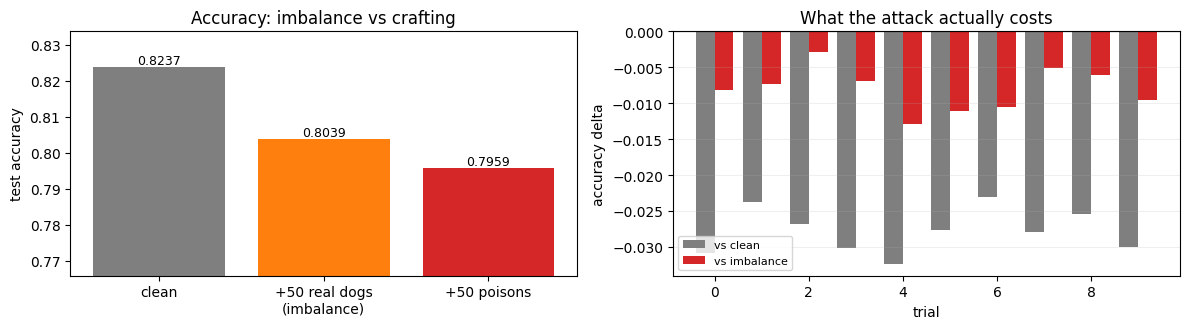

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

labels = ["clean", "+50 real dogs\n(imbalance)", "+50 poisons"]
accs   = [clean_acc, m("imbalance_accuracy"), m("poisoned_accuracy")]
axes[0].bar(labels, accs, color=["tab:gray", "tab:orange", "tab:red"])
axes[0].set(ylabel="test accuracy", title="Accuracy: imbalance vs crafting",
            ylim=(min(accs) - 0.03, max(accs) + 0.01))
for i, v in enumerate(accs):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

x = np.arange(len(results))
axes[1].bar(x - 0.2, [r["delta_vs_clean"] for r in results], 0.4, label="vs clean", color="tab:gray")
axes[1].bar(x + 0.2, [r["delta_vs_imbalance"] for r in results], 0.4, label="vs imbalance", color="tab:red")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(xlabel="trial", ylabel="accuracy delta", title="What the attack actually costs")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.2, axis="y")

fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/e2e_controls.png", dpi=150); plt.show()

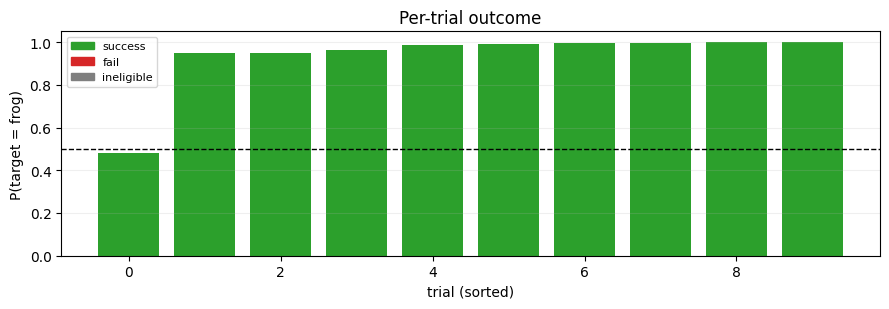

In [12]:

fig, ax = plt.subplots(figsize=(9, 3.2))
ordered = sorted(results, key=lambda r: r["confidence_in_base"])
colors = ["tab:gray" if not r["clean_correct"] else ("tab:green" if r["success"] else "tab:red")
          for r in ordered]
ax.bar(range(len(ordered)), [r["confidence_in_base"] for r in ordered], color=colors)
ax.axhline(0.5, color="black", ls="--", lw=1)
ax.set(xlabel="trial (sorted)", ylabel=f"P(target = {class_names[BASE_CLASS]})", ylim=(0, 1.05),
       title="Per-trial outcome")
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=c,label=l) for c,l in
                   [("tab:green","success"),("tab:red","fail"),("tab:gray","ineligible")]], fontsize=8)
ax.grid(alpha=0.2, axis="y")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/e2e_per_trial.png", dpi=150); plt.show()

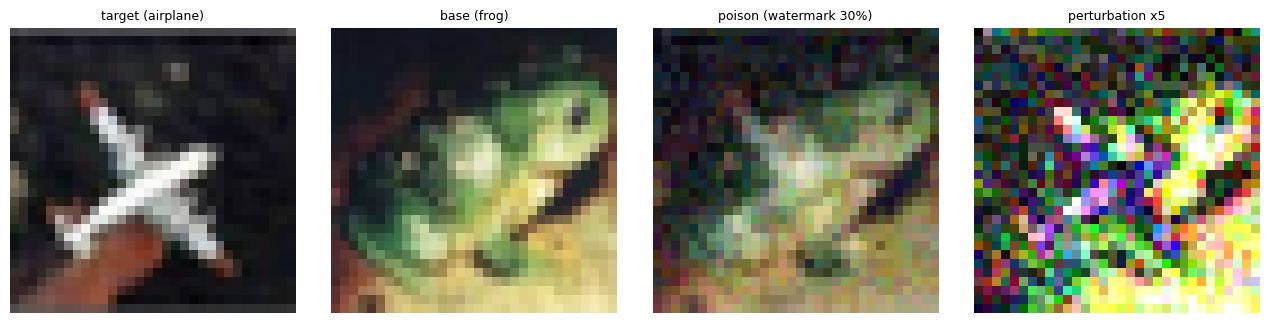

In [13]:

if saved_poisons:
    s = saved_poisons[0]
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
    panels = [(s["target"], f"target ({class_names[TARGET_CLASS]})"),
              (s["bases"][0], f"base ({class_names[BASE_CLASS]})"),
              (s["poisons"][0], f"poison (watermark {WATERMARK_OPACITY:.0%})"),
              (((s["poisons"][0] - s["bases"][0]).abs() * 5).clamp(0, 1), "perturbation x5")]
    for ax, (img, t) in zip(axes, panels):
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy()); ax.set_title(t, fontsize=9); ax.axis("off")
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/e2e_showcase.png", dpi=150); plt.show()
    for i in range(len(s["poisons"])):
        to_pil_image(s["poisons"][i]).save(OUTPUT_DIR / f"plots/e2e_poison_{i}.png")

# Defense


## Neighbour check

In [14]:

def knn_disagreement(X, y, k=DEFENSE_K):
    Xn = F.normalize(X.to(DEVICE).float(), dim=1)
    yd = y.to(DEVICE)
    sims = Xn @ Xn.T
    sims.fill_diagonal_(-2.0)
    top = sims.topk(k, dim=1)
    same = (yd[top.indices] == yd[:, None]).float()
    w = top.values.clamp(min=0) + 1e-8
    return (1.0 - (same * w).sum(1) / w.sum(1)).cpu()


@torch.no_grad()
def features_of(ex, images, bs=256):
    ex.eval()
    return torch.cat([ex(images[i:i+bs].to(DEVICE)).flatten(1).cpu()
                      for i in range(0, len(images), bs)])


defender = attacker_extractor(victim)   # the defender's own pretrained model
X_clean_feats = features_of(defender, train_images)
clean_scores  = knn_disagreement(X_clean_feats, train_labels).numpy()
print(f"clean records: mean {clean_scores.mean():.3f}  p90 {np.quantile(clean_scores,0.9):.3f}")

clean records: mean 0.000  p90 0.000


## Threshold and detection


AUC 0.4988
tau=0.025: catches 0.0% of poisons, discards 0.2% of clean records


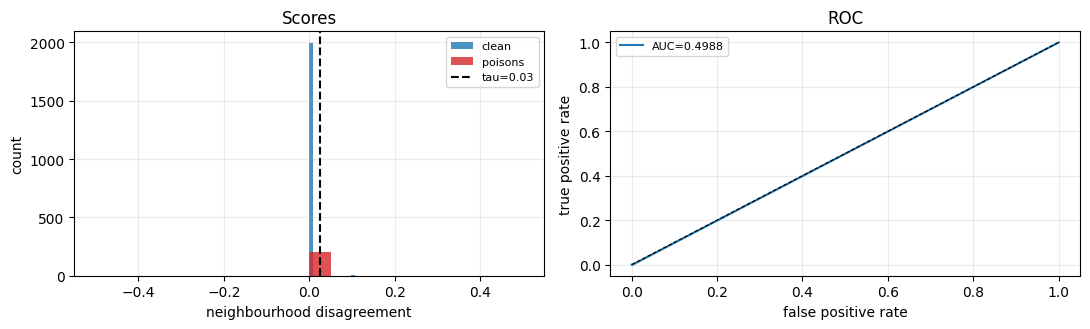

In [15]:

defense_rows = []
all_poison_scores = []

for k in sorted(kept_poisons):
    target  = chosen[k]
    poisons = kept_poisons[k]

    X_all = torch.cat([X_clean_feats, features_of(defender, poisons)])
    y_all = torch.cat([train_labels, torch.full((NUM_POISONS,), BASE_CLASS, dtype=torch.long)])
    scores = knn_disagreement(X_all, y_all).numpy()
    all_poison_scores.append(scores[len(train_labels):])
    defense_rows.append({"trial": k, "scores": scores, "poisons": poisons, "y_all": y_all,
                         "target": target})

poison_scores = np.concatenate(all_poison_scores)
y_true  = np.r_[np.ones(len(poison_scores)), np.zeros(len(clean_scores))]
y_score = np.r_[poison_scores, clean_scores]
auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

grid  = np.linspace(0, 1, 41)
sweep = [{"threshold": float(t),
          "detection_rate": float((poison_scores >= t).mean()),
          "clean_rejection_rate": float((clean_scores >= t).mean())} for t in grid]
affordable = [s for s in sweep if s["clean_rejection_rate"] <= DEFENSE_MAX_CLEAN_LOSS]
TAU = min(affordable, key=lambda s: s["threshold"])["threshold"] if affordable else 0.5
op  = min(sweep, key=lambda s: abs(s["threshold"] - TAU))
print(f"AUC {auc:.4f}")
print(f"tau={TAU:.3f}: catches {op['detection_rate']:.1%} of poisons, "
      f"discards {op['clean_rejection_rate']:.1%} of clean records")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(clean_scores, bins=40, color="tab:blue", alpha=0.8, label="clean")
axes[0].hist(poison_scores, bins=20, color="tab:red", alpha=0.8, label="poisons")
axes[0].axvline(TAU, color="black", ls="--", label=f"tau={TAU:.2f}")
axes[0].set(xlabel="neighbourhood disagreement", ylabel="count", title="Scores")
axes[1].plot(fpr, tpr, label=f"AUC={auc:.4f}"); axes[1].plot([0,1],[0,1],"k--",lw=.8)
axes[1].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
for ax in axes: ax.grid(alpha=0.25); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/e2e_defense_roc.png", dpi=150); plt.show()

json.dump({"auc": float(auc), "threshold": float(TAU),
           "detection_rate": op["detection_rate"],
           "clean_rejection_rate": op["clean_rejection_rate"],
           "sweep": sweep},
          open(OUTPUT_DIR / "e2e_defense_results.json", "w"), indent=2)


## Summary table

In [16]:

rows = [
    ("", "value"),
    ("poison budget", f"{POISON_BUDGET:.2%}  (paper: <0.1%)"),
    ("watermark opacity", f"{WATERMARK_OPACITY:.0%}"),
    ("", ""),
    ("conditional success vs clean", f"{summary['conditional_success_rate']:.1%}"),
    ("imbalance control flips same targets", f"{summary['control_flip_rate']:.1%}"),
    ("attributable to crafting", f"{summary['attributable_success_rate']:+.1%}"),
    ("", ""),
    ("accuracy delta vs clean", f"{summary['mean_delta_vs_clean']:+.4f}"),
    ("accuracy delta vs imbalance", f"{summary['mean_delta_vs_imbalance']:+.4f}"),
    ("bystander flips (poisoned / imbalance)",
     f"{summary['mean_bystander_flip_poisoned']:.1%} / {summary['mean_bystander_flip_imbalance']:.1%}"),
    ("", ""),
    ("neighbour check AUC", f"{auc:.4f}"),
    ("neighbour check: poisons caught", f"{op['detection_rate']:.1%}"),
]
w = [max(len(str(r[c])) for r in rows) for c in range(2)]
print("=" * (sum(w) + 6))
for i, r in enumerate(rows):
    print(f"  {str(r[0]):<{w[0]}}  {str(r[1]):<{w[1]}}")
    if i == 0: print("  " + "-" * (sum(w) + 2))
print("=" * (sum(w) + 6))

                                          value                
  -------------------------------------------------------------
  poison budget                           2.44%  (paper: <0.1%)
  watermark opacity                       30%                  
                                                               
  conditional success vs clean            100.0%               
  imbalance control flips same targets    0.0%                 
  attributable to crafting                +100.0%              
                                                               
  accuracy delta vs clean                 -0.0278              
  accuracy delta vs imbalance             -0.0081              
  bystander flips (poisoned / imbalance)  1.5% / 0.0%          
                                                               
  neighbour check AUC                     0.4988               
  neighbour check: poisons caught         0.0%                 


## A second defense: spectral signatures

inspecting 250 records labelled 'frog' (200 clean + 50 poisons)

spectral signature
  AUC                 0.9977   (neighbour check got 0.4988 here)
  removing the top 100  catches 50/50 poisons (100%), discards 50 clean records (25.0%)
  mean score, poisons 108.4
  mean score, clean   16.78

  Works. The poisons share a direction the clean records do not -- a property
  of the group, not of any single record's neighbourhood, which is exactly
  what the neighbour check cannot see.


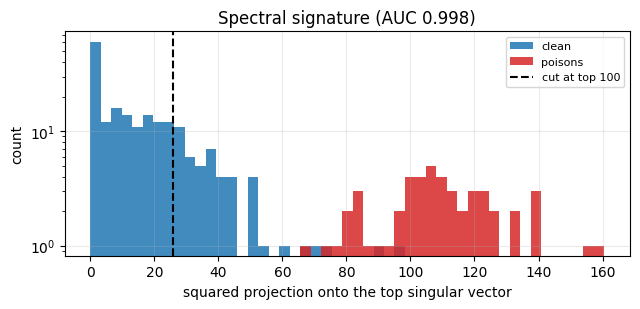

In [17]:

from sklearn.metrics import roc_auc_score

SPECTRAL_TRIAL = 0
SUSPECTED_FRACTION = 2     

target_s = chosen[SPECTRAL_TRIAL]
base_records_s = sample_records(test_source, BASE_CLASS, NUM_POISONS,
                                derive(SEED, "bases", SPECTRAL_TRIAL))
bases_s = torch.stack([r["image"] for r in base_records_s]).to(DEVICE)

if SPECTRAL_TRIAL in kept_poisons:
    poisons_s = kept_poisons[SPECTRAL_TRIAL]
else:
    seed_everything(derive(SEED, "craft", SPECTRAL_TRIAL))
    poisons_s = craft(extractor,
                      watermark(bases_s, target_s["image"].unsqueeze(0).to(DEVICE),
                                WATERMARK_OPACITY),
                      target_s["image"].unsqueeze(0).to(DEVICE).expand(NUM_POISONS, -1, -1, -1),
                      CRAFT_STEPS, CRAFT_LR, CRAFT_BETA, CRAFT_EPSILON).cpu().clamp(0, 1)

blob = torch.load(OUTPUT_DIR / "e2e_demo.pt", map_location=DEVICE, weights_only=False)
poisoned_s = build_model()
poisoned_s.load_state_dict(blob["poisoned_model"])
poisoned_s.eval()
poisoned_extractor = attacker_extractor(poisoned_s)


@torch.no_grad()
def features_of_model(model, images, bs=128):
    model.eval()
    return torch.cat([model(images[i:i + bs].to(DEVICE)).flatten(1).cpu()
                      for i in range(0, len(images), bs)])


base_mask = (train_labels == BASE_CLASS)
class_images = torch.cat([train_images[base_mask], poisons_s])
is_poison = np.r_[np.zeros(int(base_mask.sum()), bool), np.ones(NUM_POISONS, bool)]
print(f"inspecting {len(class_images)} records labelled {class_names[BASE_CLASS]!r} "
      f"({int(base_mask.sum())} clean + {NUM_POISONS} poisons)")

X_s = features_of_model(poisoned_extractor, class_images).double()

M = X_s - X_s.mean(dim=0, keepdim=True)
_, _, Vh = torch.linalg.svd(M, full_matrices=False)
spectral_scores = (M @ Vh[0]).pow(2).numpy()

spectral_auc = roc_auc_score(is_poison, spectral_scores)
cut = int(SUSPECTED_FRACTION * NUM_POISONS)
flagged_s = np.argsort(spectral_scores)[::-1][:cut]
caught_s = int(is_poison[flagged_s].sum())
lost_s = int((~is_poison[flagged_s]).sum())

print(f"\nspectral signature")
print(f"  AUC                 {spectral_auc:.4f}   (neighbour check got {auc:.4f} here)")
print(f"  removing the top {cut}  catches {caught_s}/{NUM_POISONS} poisons "
      f"({caught_s / NUM_POISONS:.0%}), discards {lost_s} clean records "
      f"({lost_s / int(base_mask.sum()):.1%})")
print(f"  mean score, poisons {spectral_scores[is_poison].mean():.4g}")
print(f"  mean score, clean   {spectral_scores[~is_poison].mean():.4g}")

if spectral_auc > 0.75:
    print("\n  Works. The poisons share a direction the clean records do not -- a property")
    print("  of the group, not of any single record's neighbourhood, which is exactly")
    print("  what the neighbour check cannot see.")
elif spectral_auc > 0.6:
    print("\n  Partial signal. Report the AUC rather than calling it a working defense.")
else:
    print("\n  No signal either. Worth reporting: with 50 poisons built from 50 DIFFERENT")
    print("  base images, the group may not be correlated enough for a rank-one")
    print("  signature to find.")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bins = np.linspace(0, spectral_scores.max(), 50)
ax.hist(spectral_scores[~is_poison], bins=bins, color="tab:blue", alpha=0.85, label="clean")
ax.hist(spectral_scores[is_poison], bins=bins, color="tab:red", alpha=0.85, label="poisons")
ax.axvline(spectral_scores[np.argsort(spectral_scores)[::-1][cut - 1]], color="black",
           ls="--", label=f"cut at top {cut}")
ax.set(xlabel="squared projection onto the top singular vector", ylabel="count",
       yscale="log", title=f"Spectral signature (AUC {spectral_auc:.3f})")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/spectral_signature.png", dpi=150); plt.show()


## Retrain on the filtered set


In [18]:

keep_mask = np.ones(len(class_images), bool)
keep_mask[flagged_s] = False

clean_base_kept = train_images[base_mask][keep_mask[:int(base_mask.sum())]]
poisons_kept    = poisons_s[keep_mask[int(base_mask.sum()):]]
other_images    = train_images[~base_mask]
other_labels    = train_labels[~base_mask]

defended_images = torch.cat([other_images, clean_base_kept, poisons_kept])
defended_labels = torch.cat([other_labels,
                             torch.full((len(clean_base_kept),), BASE_CLASS, dtype=torch.long),
                             torch.full((len(poisons_kept),),    BASE_CLASS, dtype=torch.long)])

print(f"training set after filtering: {len(defended_labels)} records "
      f"({len(poisons_kept)} poisons survived, {int(base_mask.sum()) - len(clean_base_kept)} "
      f"clean records dropped)")

m_defended = retrain_from_snapshot(defended_images, defended_labels,
                                   derive(SEED, "retrain", SPECTRAL_TRIAL))

after_pred, after_probs = predict_one(m_defended, target_s["image"])
defended_acc = float((predict_images(m_defended, test_images) == test_labels).float().mean())
row0 = results[SPECTRAL_TRIAL]

print(f"\ntarget {target_s['index']}, class {class_names[TARGET_CLASS]!r}")
print(f"  clean model      {class_names[row0['clean_prediction']]}")
print(f"  poisoned model   {class_names[row0['poisoned_prediction']]}"
      f"   (attack {'succeeded' if row0['success'] else 'failed'})")
print(f"  defended model   {class_names[after_pred]}"
      f"   (attack {'still succeeds' if after_pred == BASE_CLASS else 'stopped'})")
print(f"\ntest accuracy   clean {clean_acc:.4f}   poisoned {row0['poisoned_accuracy']:.4f}"
      f"   defended {defended_acc:.4f}")

json.dump({"auc": float(spectral_auc), "caught": caught_s, "poisons": NUM_POISONS,
           "clean_discarded": lost_s, "neighbour_auc": float(auc),
           "target_clean": class_names[row0["clean_prediction"]],
           "target_poisoned": class_names[row0["poisoned_prediction"]],
           "target_defended": class_names[after_pred],
           "attack_stopped": bool(after_pred != BASE_CLASS),
           "accuracy_clean": clean_acc,
           "accuracy_poisoned": row0["poisoned_accuracy"],
           "accuracy_defended": defended_acc},
          open(OUTPUT_DIR / "spectral_results.json", "w"), indent=2)

del m_defended
if torch.cuda.is_available():
    torch.cuda.empty_cache()

training set after filtering: 1950 records (0 poisons survived, 50 clean records dropped)

target 423, class 'airplane'
  clean model      airplane
  poisoned model   frog   (attack succeeded)
  defended model   airplane   (attack stopped)

test accuracy   clean 0.8237   poisoned 0.7929   defended 0.8152
